In [12]:
import os
import scanpy
import anndata
import scanpy as sc
import rapids_singlecell as rsc
os.listdir('../Dataset/RAW')

['GSE144744_RNA_counts.tar.gz', 'GSE194078_RAW.tar', 'GSE138266', 'GSE144744']

In [13]:
import os
import gzip
import shutil

data_dir = '../Dataset/RAW/GSE138266'
prefixes = set()

for gz_file in os.listdir(data_dir):
    gz_path = os.path.join(data_dir, gz_file)

    # Check if the file is a gzip file
    if not gz_file.endswith('.gz'):
        print(f"Skipping non-gzip file: {gz_file}")
        continue

    # Extract prefix
    for key in ['_barcodes', '_genes', '_matrix']:
        if key in gz_file:
            prefix = gz_file.split(key)[0]
            prefixes.add(prefix)
            break

    # Unzip file
    unzipped_file = gz_file[:-3]  # remove '.gz'
    unzipped_path = os.path.join(data_dir, unzipped_file)

    if not os.path.exists(unzipped_path):  # avoid overwriting
        try:
            with gzip.open(gz_path, 'rb') as f_in, open(
                unzipped_path, 'wb'
            ) as f_out:
                shutil.copyfileobj(f_in, f_out)
                print(f"Unzipped: {unzipped_path}")
        except gzip.BadGzipFile:
            print(f"Failed to unzip (BadGzipFile): {gz_path}")
        except Exception as e:
            print(f"An unexpected error occurred: {e}")
    else:
        print(f"Already unzipped: {unzipped_path}")

print(prefixes)
print(len(prefixes))

Already unzipped: ../Dataset/RAW/GSE138266/GSM4104122_MS19270_CSF_GRCh38_barcodes.tsv
Already unzipped: ../Dataset/RAW/GSE138266/GSM4104122_MS19270_CSF_GRCh38_genes.tsv
Already unzipped: ../Dataset/RAW/GSE138266/GSM4104122_MS19270_CSF_GRCh38_matrix.mtx
Already unzipped: ../Dataset/RAW/GSE138266/GSM4104123_MS58637_CSF_GRCh38_barcodes.tsv
Already unzipped: ../Dataset/RAW/GSE138266/GSM4104123_MS58637_CSF_GRCh38_genes.tsv
Already unzipped: ../Dataset/RAW/GSE138266/GSM4104123_MS58637_CSF_GRCh38_matrix.mtx
Already unzipped: ../Dataset/RAW/GSE138266/GSM4104124_MS71658_CSF_GRCh38_barcodes.tsv
Already unzipped: ../Dataset/RAW/GSE138266/GSM4104124_MS71658_CSF_GRCh38_genes.tsv
Already unzipped: ../Dataset/RAW/GSE138266/GSM4104124_MS71658_CSF_GRCh38_matrix.mtx
Already unzipped: ../Dataset/RAW/GSE138266/GSM4104125_MS49131_CSF_GRCh38_barcodes.tsv
Already unzipped: ../Dataset/RAW/GSE138266/GSM4104125_MS49131_CSF_GRCh38_genes.tsv
Already unzipped: ../Dataset/RAW/GSE138266/GSM4104125_MS49131_CSF_GRCh38

In [14]:
import re
import celltypist
from celltypist import models
import pandas as pd
def parse_sample_name(sample_name):
    match = re.search(r'_(PTC|MS|PST)(\d+?)_(CSF|PBMCs)_', sample_name)
    if match:
        patient_code_type = match.group(1)
        patient_code = match.group(2)
        sample_type = match.group(3)
        return patient_code_type, patient_code, sample_type
    else:
        return None, None, None


def process_adata(adata):
    print(adata)
    sc.pp.normalize_total(adata, target_sum=1e4)
    # Logarithmize the data
    sc.pp.log1p(adata)
    # Mitochondrial genes, "MT-" for human, "Mt-" for mouse
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(
        adata, qc_vars=["mt"], inplace=True, log1p=True
    )
    # Filtering
    sc.pp.filter_cells(adata, max_genes=3700)
    sc.pp.filter_cells(adata, max_counts=20000)
    sc.pp.filter_cells(adata, min_genes=100)
    adata = adata[adata.obs['pct_counts_mt'] < 6, :]
    adata.layers["counts"] = adata.X.copy()
    # Normalizing to median total counts
    
    return adata

def annotate_adata(adata):
    predictions = celltypist.annotate(adata.copy(), model = 'Immune_All_Low.pkl', majority_voting = True)
    adata.obs = pd.concat([adata.obs, predictions.predicted_labels], axis=1)
    return adata
    
adata_list = []
for prefix in prefixes:
    adata = sc.read_10x_mtx('../Dataset/RAW/GSE138266',
                            prefix=prefix+"_")

    # Parse the sample name to get condition, sample, and tissue
    patient_code_type, patient_code, tissue = parse_sample_name(prefix)

    # Add the information to the AnnData object's obs attribute
    if patient_code_type and patient_code and tissue:
        adata.obs['condition'] = "MS" if patient_code_type == "MS" else "CTRL"
        adata.obs['sample'] = patient_code
        adata.obs['tissue'] = tissue
    print("Cell count before filtering: ", adata.shape)
    adata = process_adata(adata)
    print("Cell count after filtering: ", adata.shape)
    adata = annotate_adata(adata)
    print(adata)
    adata_list.append(adata)

Cell count before filtering:  (5164, 33694)
AnnData object with n_obs × n_vars = 5164 × 33694
    obs: 'condition', 'sample', 'tissue'
    var: 'gene_ids'


🔬 Input data has 5159 cells and 33694 genes
🔗 Matching reference genes in the model


Cell count after filtering:  (5159, 33694)


🧬 5656 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


AnnData object with n_obs × n_vars = 5159 × 33694
    obs: 'condition', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'predicted_labels', 'over_clustering', 'majority_voting'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p'
    layers: 'counts'
Cell count before filtering:  (1106, 33694)
AnnData object with n_obs × n_vars = 1106 × 33694
    obs: 'condition', 'sample', 'tissue'
    var: 'gene_ids'
Cell count after filtering:  (1083, 33694)


...

AnnData object with n_obs × n_vars = 1517 × 33694
    obs: 'condition', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'predicted_labels', 'over_clustering', 'majority_voting'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p'
    layers: 'counts'
Cell count before filtering:  (3972, 33694)
AnnData object with n_obs × n_vars = 3972 × 33694
    obs: 'condition', 'sample', 'tissue'
    var: 'gene_ids'


🔬 Input data has 3930 cells and 33694 genes
🔗 Matching reference genes in the model


Cell count after filtering:  (3930, 33694)


🧬 5656 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


AnnData object with n_obs × n_vars = 3930 × 33694
    obs: 'condition', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'predicted_labels', 'over_clustering', 'majority_voting'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p'
    layers: 'counts'


In [15]:
import anndata
adata = anndata.concat(adata_list, join='inner', merge="same")
print(adata)

AnnData object with n_obs × n_vars = 77426 × 33694
    obs: 'condition', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'predicted_labels', 'over_clustering', 'majority_voting'
    var: 'gene_ids', 'mt'
    layers: 'counts'


... storing 'condition' as categorical
... storing 'sample' as categorical
... storing 'tissue' as categorical


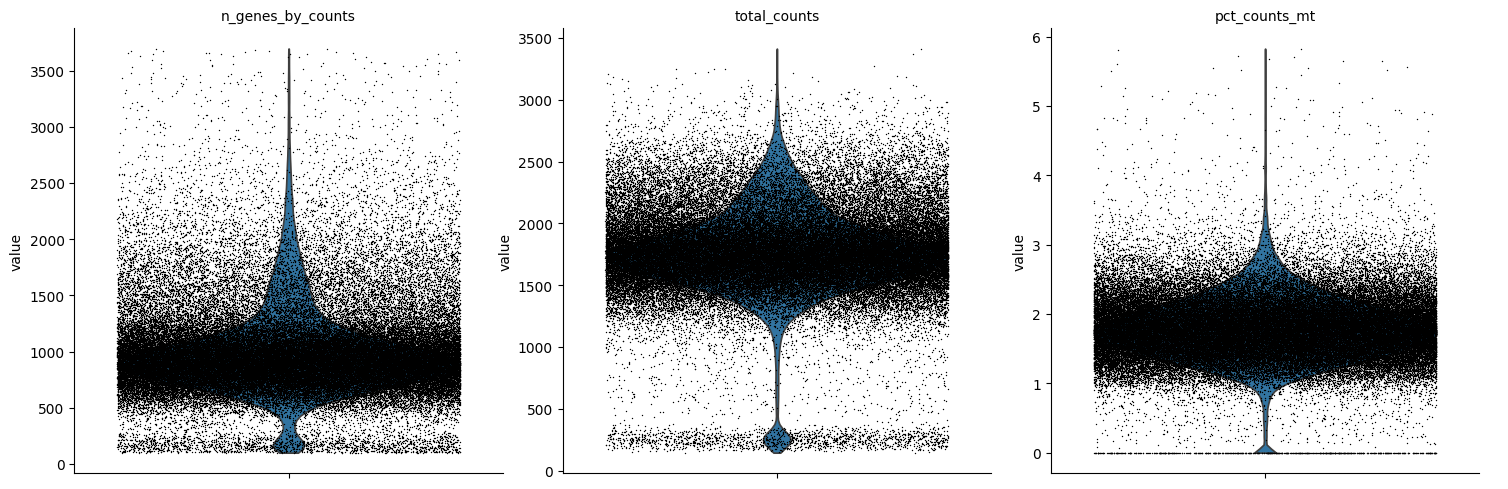

In [16]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [ ]:
import numpy as np
def remove_zero_expressed_genes(adata):
  """
  Removes genes with zero expression in all cells from an AnnData object.

  Args:
    adata: An AnnData object.

  Returns:
    An AnnData object with zero-expressed genes removed.
  """
  # Calculate the mean expression for each gene
  gene_means = adata.X.mean(axis=0)
  
  # Identify genes with zero mean expression
  zero_expressed_genes = gene_means == 0

  # Get the indices of the genes to keep
  genes_to_keep = ~zero_expressed_genes

  # Subset the AnnData object to keep only the genes with non-zero expression
  adata = adata[:, genes_to_keep]

  print(f"Removed {np.sum(zero_expressed_genes)} genes with zero expression.")
  return adata
adata = remove_zero_expressed_genes(adata)
print(adata)

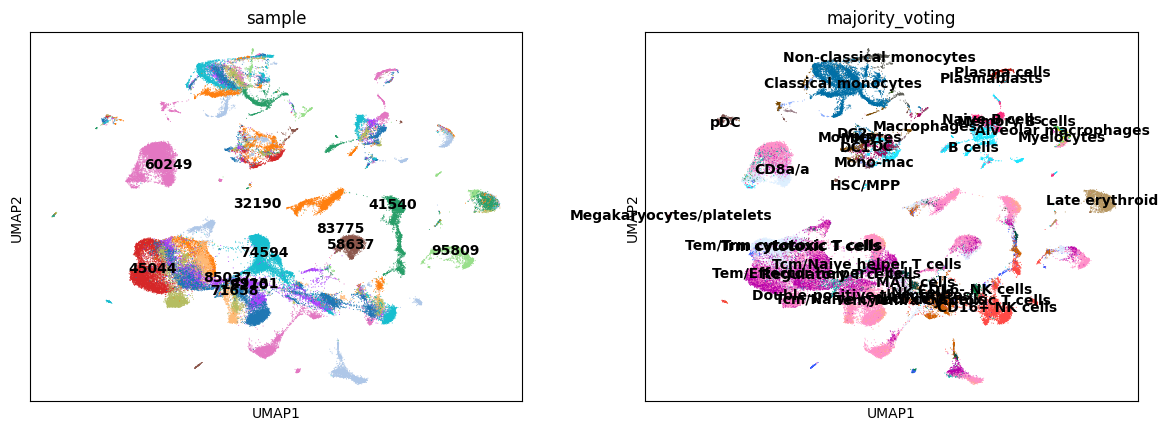

In [17]:
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata, min_dist=0.3, spread=1.0)

sc.pl.umap(
    adata,
    color=["sample", "majority_voting"],
    # Setting a smaller point size to get prevent overlap
    size=2,
    legend_loc = 'on data'
)

In [ ]:
import scanpy as sc
import pandas as pd

# Value counts of 'majority_voting' for each 'sample'
value_counts = adata.obs.groupby('sample')['majority_voting'].value_counts()

# Print the value counts (Series format)
print("Value Counts (Series):")
print(value_counts)

# Unstack the value counts into a DataFrame for better readability
value_counts_df = adata.obs.groupby('sample')['majority_voting'].value_counts().unstack(fill_value=0)

# Print the DataFrame
print("\nValue Counts (DataFrame):")
print(value_counts_df)


# Add annotations for CD4, B, and Treg cells based on 'majority_voting'

# Example: Assuming 'majority_voting' contains cell type labels

def annotate_cell_types(adata):
    """Annotates cells based on 'majority_voting' for CD4, B, and Treg.

    Args:
        adata: AnnData object containing single-cell data.
    """
    adata.obs['is_cd4'] = adata.obs['majority_voting'].str.startswith('CD4', na=False)
    adata.obs['is_b_cell'] = adata.obs['majority_voting'].str.startswith('B', na=False)
    adata.obs['is_treg'] = adata.obs['majority_voting'].str.contains('Treg', na=False, case=False) #Case insensitive check


# Apply the annotation function
annotate_cell_types(adata)

# Print summary statistics
print("\nSummary Statistics:")
print(f"Number of CD4+ cells: {adata.obs['is_cd4'].sum()}")
print(f"Number of B cells: {adata.obs['is_b_cell'].sum()}")
print(f"Number of Treg cells: {adata.obs['is_treg'].sum()}")

# Optionally, visualize these annotations on UMAP plots
sc.pl.umap(adata, color=['is_cd4', 'is_b_cell', 'is_treg'], title=['CD4+ Cells', 'B Cells', 'Treg Cells'])


In [19]:
adata.write("../Dataset/PreProcessed/GSE138266.h5ad", compression="gzip")

In [20]:
import scanpy as sc

# Load the AnnData object
adata = sc.read_h5ad("../Dataset/PreProcessed/GSE138266.h5ad")

# Filter the AnnData object to keep only cells where 'tissue' == 'PBMC'
adata = adata[adata.obs['tissue'] == 'PBMCs', :]

# (Optional) Print the shape of the filtered AnnData object to confirm
print(f"Shape of filtered AnnData object: {adata.shape}")

# (Optional) Save the filtered AnnData object to a new file
adata.write("../Dataset/PreProcessed/GSE138266_PBMC.h5ad", compression="gzip")

Shape of filtered AnnData object: (42230, 33694)


In [21]:
import anndata
import scanpy as sc
adata  = sc.read_h5ad("../Dataset/PreProcessed/GSE138266.h5ad")
adata = adata[adata.obs['tissue'] == 'CSF', :]
print(f"Shape of filtered AnnData object: {adata.shape}")
adata.write("../Dataset/PreProcessed/GSE138266_CSF.h5ad", compression="gzip")

Shape of filtered AnnData object: (35196, 33694)
